# Smart Meter MDMS - Complete Pipeline Analysis

End-to-End Pipeline:
Ingestion → Cleaning → Feature Engineering → Validation → Storage → Analysis → Visualization → Reporting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
PROJECT_ROOT = Path.cwd().parent if "notebooks" in str(Path.cwd()) else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
PLOTS_DIR = PROJECT_ROOT / "outputs" / "plots"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
df = pd.read_csv(DATA_PROCESSED / "featured_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (24400, 33)


In [9]:
print(df.head())
print(df.info())

            Timestamp  Meter_ID Zone_ID  Voltage_V  Current_A  \
0 2021-01-01 04:00:00  MTR-4450   North     225.44      5.404   
1 2021-01-01 13:00:00  MTR-4450   North     231.37      4.687   
2 2021-01-01 14:00:00  MTR-4450   North     230.23      4.163   
3 2021-01-01 16:00:00  MTR-4450   North     235.03      4.945   
4 2021-01-01 18:00:00  MTR-4450   North     232.73      4.636   

   Active_Power_kW  Reactive_Power_kW  Apparent_Power_kVA  Frequency_Hz  \
0            1.143              0.437               1.224        49.949   
1            1.043              0.337               1.096        50.052   
2            0.923              0.289               0.967        50.007   
3            1.131              0.368               1.189        50.018   
4            1.072              0.236               1.097        50.084   

   Sub_Meter_Kitchen  ...  peak_hour_flag  power_factor  \
0              0.136  ...               0      0.933824   
1              0.010  ...               

In [10]:
print("DATA QUALITY SUMMARY")
print("-" * 50)

duplicates = df.duplicated().sum()
missing = df.isnull().sum().sum()

print("Total Records:", len(df))
print("Duplicate Rows:", duplicates)
print("Missing Values:", missing)

DATA QUALITY SUMMARY
--------------------------------------------------
Total Records: 24400
Duplicate Rows: 0
Missing Values: 2222


In [11]:
print("STATISTICS SUMMARY")
print("-" * 50)

numeric_cols = df.select_dtypes(include=np.number).columns
stats_df = df[numeric_cols].describe().T

print(stats_df[['mean','std','min','max']].head(10))

STATISTICS SUMMARY
--------------------------------------------------
                           mean        std       min       max
Voltage_V            230.820067  23.202315   218.500   646.480
Current_A             10.485581   7.055238     0.275    88.315
Active_Power_kW        2.658905   8.145522     0.000   148.558
Reactive_Power_kW      1.245878   5.027608     0.000    92.068
Apparent_Power_kVA     2.943931   9.533769     0.000   174.774
Frequency_Hz          50.000060   0.045428    49.827    50.179
Sub_Meter_Kitchen      0.248541   0.237937     0.000     0.947
Sub_Meter_HVAC         1.194767   1.233774     0.000     5.821
Outdoor_Temp_C        29.095676   6.584756    13.830    44.160
year                2021.000000   0.000000  2021.000  2021.000


In [12]:
print("FEATURE ENGINEERING SUMMARY")
print("-" * 50)

print("Total Columns:", len(df.columns))
print("Sample Columns:", list(df.columns)[:10])

FEATURE ENGINEERING SUMMARY
--------------------------------------------------
Total Columns: 33
Sample Columns: ['Timestamp', 'Meter_ID', 'Zone_ID', 'Voltage_V', 'Current_A', 'Active_Power_kW', 'Reactive_Power_kW', 'Apparent_Power_kVA', 'Frequency_Hz', 'Sub_Meter_Kitchen']


## Visualization Set 1: Hourly vs Daily Trends

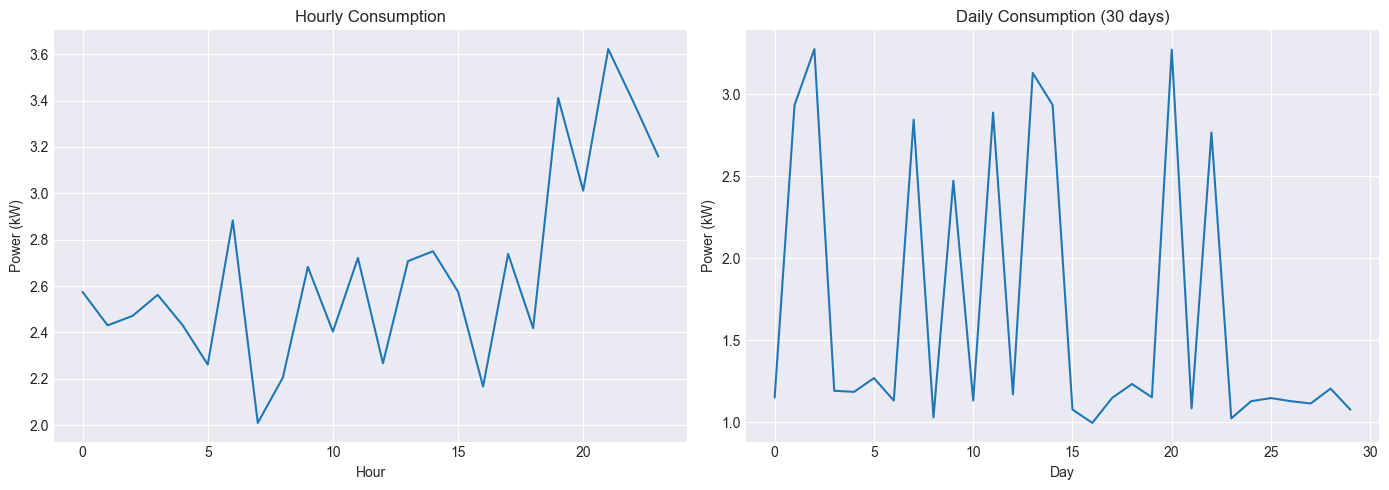

In [13]:
hourly = df.groupby(df['Timestamp'].dt.hour)['Active_Power_kW'].mean()
daily = df.groupby(df['Timestamp'].dt.date)['Active_Power_kW'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(hourly.index, hourly.values)
axes[0].set_title("Hourly Consumption")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Power (kW)")

axes[1].plot(range(len(daily[:30])), daily.values[:30])
axes[1].set_title("Daily Consumption (30 days)")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Power (kW)")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "comparison_hourly_daily.png", dpi=300)
plt.show()

## Visualization Set 2: Zone vs Peak Analysis

In [ ]:
if 'Zone_ID' in df.columns:
    zone = df.groupby('Zone_ID')['Active_Power_kW'].mean()
    peak = df.groupby(df['Timestamp'].dt.hour)['Active_Power_kW'].max()

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    axes[0].bar(zone.index.astype(str), zone.values)
    axes[0].set_title("Zone Consumption")
    axes[0].set_xlabel("Zone")
    axes[0].set_ylabel("Power (kW)")

    axes[1].plot(peak.index, peak.values)
    axes[1].set_title("Peak Hour Pattern")
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Max Power (kW)")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "comparison_zone_peak.png", dpi=300)
    plt.show()

## Visualization Set 3: Power Relationships

In [ ]:
if 'Active_Power_kW' in df.columns and 'Reactive_Power_kW' in df.columns:

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    axes[0].scatter(df['Active_Power_kW'], df['Reactive_Power_kW'], alpha=0.3)
    axes[0].set_title("Active vs Reactive")
    axes[0].set_xlabel("Active Power (kW)")
    axes[0].set_ylabel("Reactive Power (kW)")

    axes[1].hist(df['Active_Power_kW'], bins=40)
    axes[1].set_title("Power Distribution")
    axes[1].set_xlabel("Power (kW)")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "comparison_power.png", dpi=300)
    plt.show()

In [16]:
print("ANOMALY SUMMARY")

if 'is_anomaly' in df.columns:
    print("Anomalies detected:", df['is_anomaly'].sum())
else:
    print("No anomaly column found")

ANOMALY SUMMARY
Anomalies detected: 214


In [17]:
print("FINAL INSIGHTS")
print("-" * 50)

print("Total Records:", len(df))
print("Total Features:", len(df.columns))
print("Data Quality Score:",
      100 - (df.isnull().sum().sum() / (len(df)*len(df.columns)) * 100))

FINAL INSIGHTS
--------------------------------------------------
Total Records: 24400
Total Features: 33
Data Quality Score: 99.72404371584699


In [18]:
print("OUTPUT VERIFICATION")
print("-" * 50)

print("Plots Directory:", PLOTS_DIR)
print("Reports Directory:", REPORTS_DIR)

OUTPUT VERIFICATION
--------------------------------------------------
Plots Directory: c:\Smart Meter Data Systems\outputs\plots
Reports Directory: c:\Smart Meter Data Systems\outputs\reports
